
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

Bernardo Alejandro Mendoza Montes - 1001363373

In [21]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [20]:
# 1. Profundidades del pico

# Pedir el valor maximo de la columna "profundida de pico" en la isla Torgensen
profundidad_max = df[df['isla'] == 'Torgersen']['profundidad_pico (mm)'].max()

# Pedir el valor minimo de la columna "profundida de pico" en la isla Torgensen
profundidad_min = df['profundidad_pico (mm)'].min()

print("Profundidad de pico máxima [mm]:", profundidad_max)
print("Profundidad de pico mínima [mm]:", profundidad_min)

Profundidad de pico máxima [mm]: 21.5
Profundidad de pico mínima [mm]: 13.1


In [12]:
# 2. Información del pingüino más gordo

# Busca el índice cuyo valor de masa corporal es el maximo
indice = np.argmax(df['masa_corporal (g)'])

# Seleciona el valor del "isla" del elemento cuyo índice tiene la mayor masa corporal
isla = df.loc[indice, 'isla']

# Seleciona el valor del "especie" del elemento cuyo índice tiene la mayor masa corporal
especie = df.loc[indice, 'especie']

# Seleciona el valor del "genero" del elemento cuyo índice tiene la mayor masa corporal
genero = df.loc[indice, 'genero']

print("Índice del pingüno más gordo:", indice)
print("Isla del pingüino más gordo:", isla)
print("Especie del pingüino más gordo:", especie)
print("Género del pingüino más gordo:", genero)

"""
Hay formas de hacerlo en menos lineas trabajando con los arrays directamente
en lugar de elemento a elemento
"""

Índice del pingüno más gordo: 231
Isla del pingüino más gordo: Biscoe
Especie del pingüino más gordo: Gentoo
Género del pingüino más gordo: Male


In [19]:
# 3. Masa corporal promedio de todos los pingünos macho que no son gentoo

"""
Utilizamos condicionales logicos para filtrar por especie y genero la columna de masa corporal.
Luego usamos .mean() para obtener el promedio de la columna.
"""

promedio_masa_cond = df[(df['especie'] != 'Gentoo') & (df['genero'] == 'Male')]['masa_corporal (g)'].mean()

print("La masa corporal promedio [g] de los pingüinos macho que no son Gentoo es:", promedio_masa_cond)


La masa corporal promedio [g] de los pingüinos macho que no son Gentoo es: 4010.2803738317757


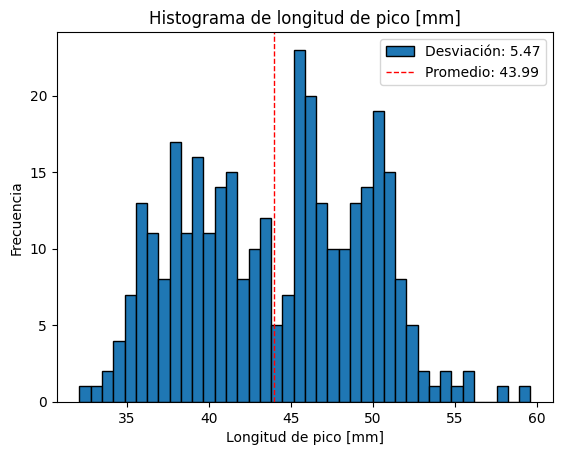

In [45]:
# 4. Grafica de distribución de longitud de pico

# Obtenemos el promedio y la desviación estandar de la columna "longitud de pico"

promedio_longitud_pico = df['longitud_pico (mm)'].mean()
desv_longitud_pico = df['longitud_pico (mm)'].std()

# Graficamos la distribución de la columna "longitud de pico" como histograma

plt.hist(df['longitud_pico (mm)'], bins=40, label=f'Desviación: {desv_longitud_pico:.2f}', edgecolor='black')
plt.axvline(promedio_longitud_pico, color='red', linestyle='dashed', linewidth=1, label=f'Promedio: {promedio_longitud_pico:.2f}')
plt.title('Histograma de longitud de pico [mm]')
plt.xlabel('Longitud de pico [mm]')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [40]:
# 5.1. Islas y especies en los datos

# Usamos .unique() para obtener los valores de las columnas sin repetirlos

islas_tipo = df['isla'].unique()
especies_tipo = df['especie'].unique()

print("Las islas presentes en los datos son:", islas_tipo)
print("Las especies presentes en los datos son:", especies_tipo)

Las islas presentes en los datos son: ['Torgersen' 'Biscoe' 'Dream']
Las especies presentes en los datos son: ['Adelie' 'Chinstrap' 'Gentoo']


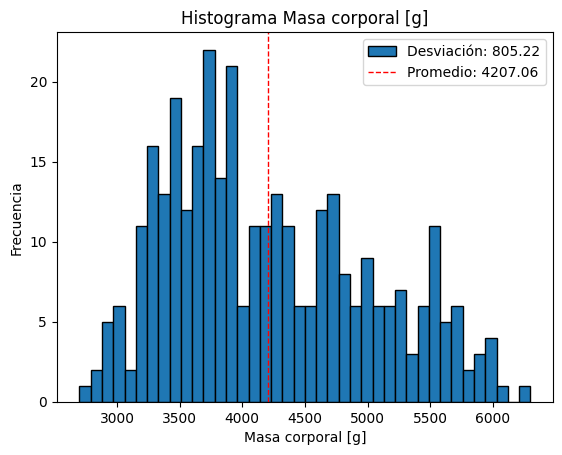

In [44]:
# 5.2. Histograma de masa corporal

# Obtenemos el promedio y la desviación estandar de la columna "Masa corporal"

promedio_masa= df['masa_corporal (g)'].mean()
desv_masa = df['masa_corporal (g)'].std()

# Graficamos la distribución de la columna "longitud de pico" como histograma

plt.hist(df['masa_corporal (g)'], bins=40, label=f'Desviación: {desv_masa:.2f}', edgecolor='black')
plt.axvline(promedio_masa, color='red', linestyle='dashed', linewidth=1, label=f'Promedio: {promedio_masa:.2f}')
plt.title('Histograma Masa corporal [g]')
plt.xlabel('Masa corporal [g]')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

5. REGULAR...

MUY BIEN. NOTA 5.0